# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [3]:
# Ruta al dataset (ajusta si es necesario)
DATA_PATH = r'online_retail_II.xlsx'

# Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
#df = pd.read_excel(DATA_PATH, sheet_name=1)
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


In [4]:
df.to_pickle('online_retail.pkl')
#df = pd.read_pickle('online_retail.pkl')

## 2. Primera inspección

In [5]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [7]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

## 3. Calidad de datos

In [8]:
# --- Nulos por columna ---
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
print("Nulos por columna:")
print(pd.DataFrame({"count": nulos, "%": nulos_pct}))

# --- Filas duplicadas exactas ---
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados:,} ({duplicados/len(df)*100:.2f}%)")

# --- Cancelaciones (Invoice empieza por C) ---
cancelaciones = df["Invoice"].astype(str).str.startswith("C")
print(f"\nFacturas canceladas: {cancelaciones.sum():,} ({cancelaciones.sum()/len(df)*100:.2f}%)")

# --- Precios y cantidades anomalos ---
print(f"\nFilas con Quantity <= 0: {(df['Quantity'] <= 0).sum():,}")
print(f"Filas con Price <= 0:    {(df['Price'] <= 0).sum():,}")

Nulos por columna:
              count      %
Invoice           0   0.00
StockCode         0   0.00
Description    4382   0.41
Quantity          0   0.00
InvoiceDate       0   0.00
Price             0   0.00
Customer ID  243007  22.77
Country           0   0.00

Filas duplicadas: 34,335 (3.22%)

Facturas canceladas: 19,494 (1.83%)

Filas con Quantity <= 0: 22,950
Filas con Price <= 0:    6,207


## 4. Estadísticas descriptivas

Análisis de negocio: revenue, temporalidad, concentración de clientes (Pareto), países y productos estrella.

In [9]:
# Preparacion: revenue por linea
df['Revenue'] = df['Quantity'] * df['Price']

print('=== DATASET GENERAL ===')
print('Periodo:          {} a {}'.format(df['InvoiceDate'].min().date(), df['InvoiceDate'].max().date()))
print('Clientes unicos:  {:,}'.format(df['Customer ID'].nunique()))
print('Facturas unicas:  {:,}'.format(df['Invoice'].nunique()))
print('Productos unicos: {:,}'.format(df['StockCode'].nunique()))
print('Paises:           {:,}'.format(df['Country'].nunique()))
print('Revenue total:    £{:,.0f}'.format(df['Revenue'].sum()))


=== DATASET GENERAL ===
Periodo:          2009-12-01 a 2011-12-09
Clientes unicos:  5,942
Facturas unicas:  53,628
Productos unicos: 5,305
Paises:           43
Revenue total:    £19,287,251


Clientes que generan el 80% del revenue: 1,352 (23.0% del total)


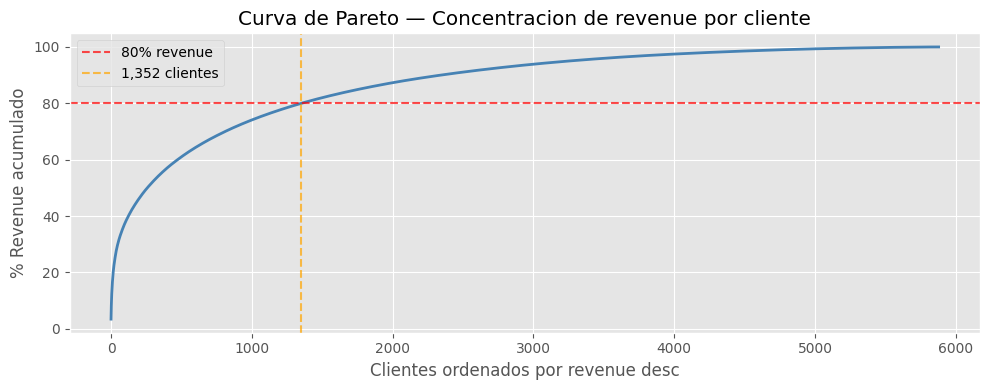

In [10]:
# Pareto: cuantos clientes generan el 80% del revenue
revenue_cliente = (
    df[df['Customer ID'].notna() & (df['Revenue'] > 0)]
    .groupby('Customer ID')['Revenue'].sum()
    .sort_values(ascending=False)
)
revenue_acum = revenue_cliente.cumsum() / revenue_cliente.sum()
clientes_80 = (revenue_acum <= 0.80).sum()
pct_clientes = clientes_80 / len(revenue_cliente) * 100
print('Clientes que generan el 80% del revenue: {:,} ({:.1f}% del total)'.format(clientes_80, pct_clientes))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(revenue_acum)), revenue_acum.values * 100, color='steelblue', linewidth=2)
ax.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% revenue')
ax.axvline(clientes_80, color='orange', linestyle='--', alpha=0.7, label='{:,} clientes'.format(clientes_80))
ax.set_xlabel('Clientes ordenados por revenue desc')
ax.set_ylabel('% Revenue acumulado')
ax.set_title('Curva de Pareto — Concentracion de revenue por cliente')
ax.legend()
plt.tight_layout()
plt.show()


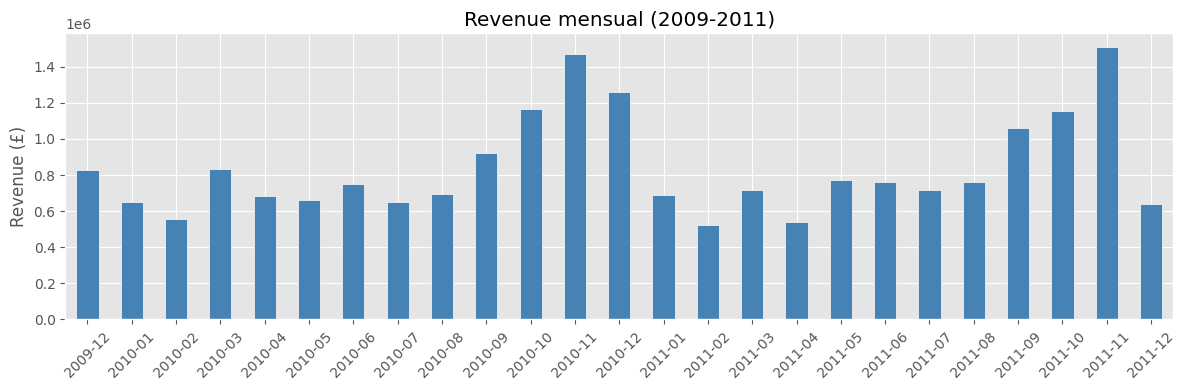

In [11]:
# Estacionalidad: revenue mensual
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
revenue_mes = df[df['Revenue'] > 0].groupby('YearMonth')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
revenue_mes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Revenue mensual (2009-2011)')
ax.set_xlabel('')
ax.set_ylabel('Revenue (£)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


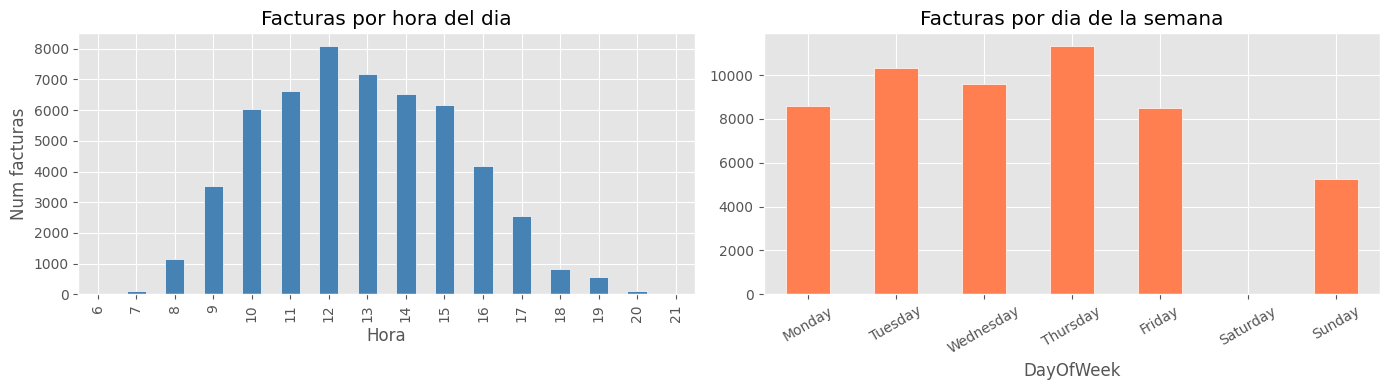

In [12]:
# Horarios de compra
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

dias_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
compras_hora = df.groupby('Hour')['Invoice'].nunique()
compras_dia = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(dias_orden)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
compras_hora.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Facturas por hora del dia')
ax1.set_xlabel('Hora')
ax1.set_ylabel('Num facturas')
compras_dia.plot(kind='bar', ax=ax2, color='coral', edgecolor='white')
ax2.set_title('Facturas por dia de la semana')
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


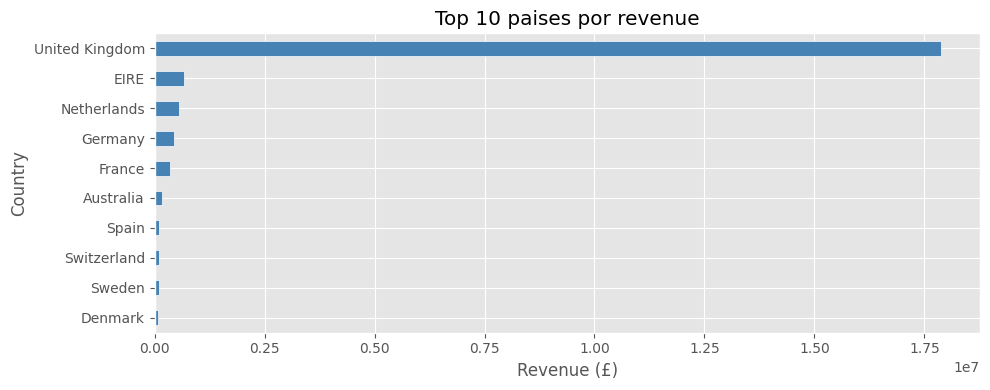

In [13]:
# Top 10 paises por revenue
top_paises = (
    df[df['Revenue'] > 0]
    .groupby('Country')['Revenue'].sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
top_paises.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 10 paises por revenue')
ax.set_xlabel('Revenue (£)')
plt.tight_layout()
plt.show()


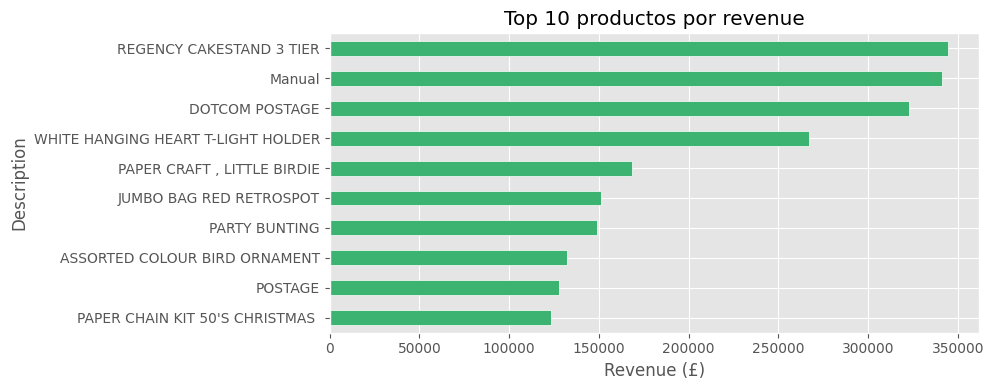

In [14]:
# Top 10 productos por revenue
top_productos = (
    df[df['Revenue'] > 0]
    .groupby('Description')['Revenue'].sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
top_productos.plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 10 productos por revenue')
ax.set_xlabel('Revenue (£)')
plt.tight_layout()
plt.show()


## 5. Visualizaciones

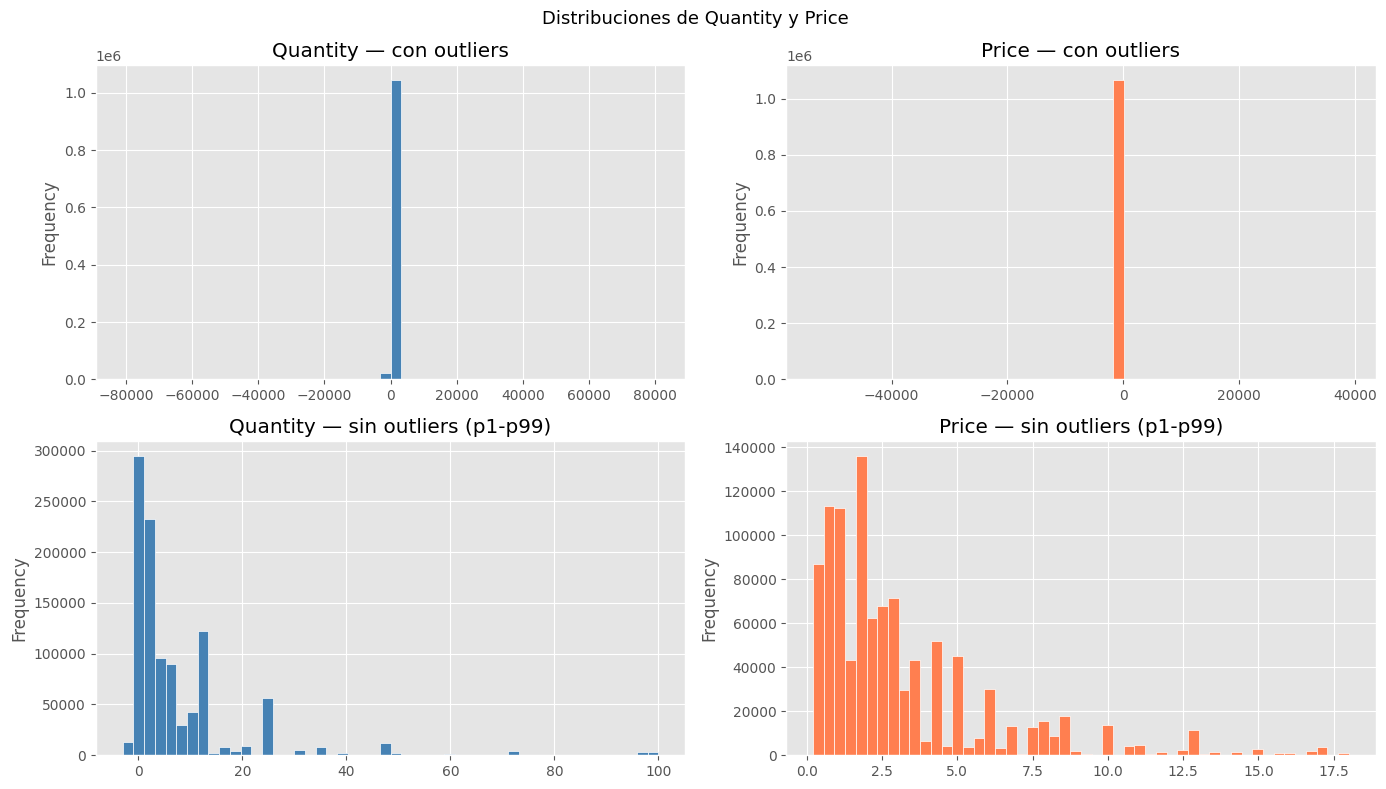

In [15]:
# Distribucion de Quantity y Price — con vs sin outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df['Quantity'].plot(kind='hist', bins=50, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Quantity — con outliers')

df['Price'].plot(kind='hist', bins=50, ax=axes[0,1], color='coral', edgecolor='white')
axes[0,1].set_title('Price — con outliers')

q_low, q_high = df['Quantity'].quantile(0.01), df['Quantity'].quantile(0.99)
p_low, p_high = df['Price'].quantile(0.01), df['Price'].quantile(0.99)

df[df['Quantity'].between(q_low, q_high)]['Quantity'].plot(kind='hist', bins=50, ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Quantity — sin outliers (p1-p99)')

df[df['Price'].between(p_low, p_high)]['Price'].plot(kind='hist', bins=50, ax=axes[1,1], color='coral', edgecolor='white')
axes[1,1].set_title('Price — sin outliers (p1-p99)')

plt.suptitle('Distribuciones de Quantity y Price', fontsize=13)
plt.tight_layout()
plt.show()


Revenue por cliente:
count      £5,878
mean       £3,019
std       £14,738
min            £3
25%          £349
50%          £899
75%        £2,307
max      £608,822
Name: Revenue, dtype: str


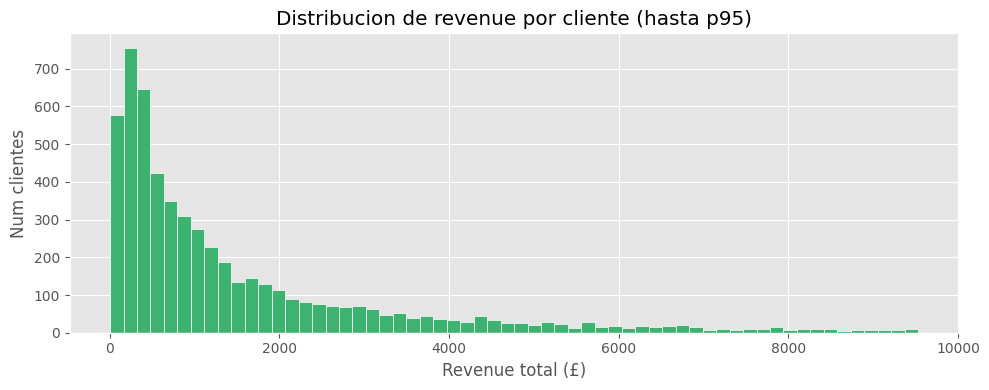

In [16]:
# Distribucion de revenue por cliente
revenue_por_cliente = (
    df[df['Customer ID'].notna() & (df['Revenue'] > 0)]
    .groupby('Customer ID')['Revenue'].sum()
)
print('Revenue por cliente:')
print(revenue_por_cliente.describe().apply(lambda x: '£{:,.0f}'.format(x)))

lim = revenue_por_cliente.quantile(0.95)
fig, ax = plt.subplots(figsize=(10, 4))
revenue_por_cliente[revenue_por_cliente <= lim].plot(kind='hist', bins=60, ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Distribucion de revenue por cliente (hasta p95)')
ax.set_xlabel('Revenue total (£)')
ax.set_ylabel('Num clientes')
plt.tight_layout()
plt.show()


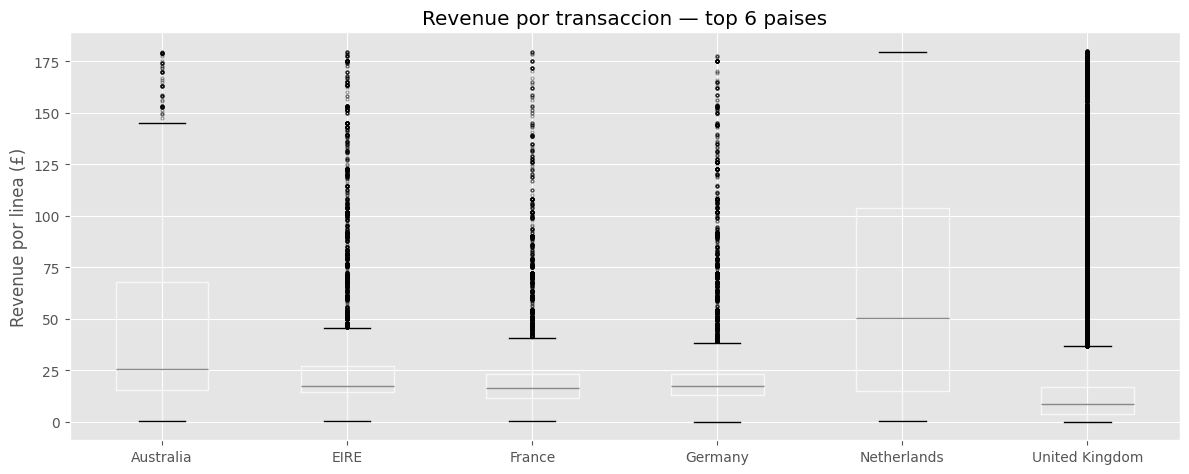

In [17]:
# Boxplot de revenue por transaccion — top 6 paises
top6_paises = (
    df[df['Revenue'] > 0].groupby('Country')['Revenue'].sum()
    .sort_values(ascending=False).head(6).index.tolist()
)
df_top = df[df['Country'].isin(top6_paises) & (df['Revenue'] > 0) & (df['Revenue'] < df['Revenue'].quantile(0.99))]

fig, ax = plt.subplots(figsize=(12, 5))
df_top.boxplot(column='Revenue', by='Country', ax=ax,
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Revenue por transaccion — top 6 paises')
ax.set_xlabel('')
ax.set_ylabel('Revenue por linea (£)')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 6. Limpieza de datos

Eliminamos cancelaciones, filas sin Customer ID, precios/cantidades negativos y duplicados.

In [ ]:
df_clean = df.copy()
print('Filas originales: {:,}'.format(len(df_clean)))

df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print('Tras eliminar cancelaciones: {:,}'.format(len(df_clean)))

df_clean = df_clean[df_clean['Customer ID'].notna()]
print('Tras eliminar sin Customer ID: {:,}'.format(len(df_clean)))

df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print('Tras eliminar Quantity/Price <= 0: {:,}'.format(len(df_clean)))

df_clean = df_clean.drop_duplicates()
print('Tras eliminar duplicados: {:,}'.format(len(df_clean)))

df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
print('Filas eliminadas: {:,} ({:.1f}%)'.format(len(df)-len(df_clean), (len(df)-len(df_clean))/len(df)*100))


## 7. Feature Engineering

Construimos variables RFM por cliente con datos anteriores a la fecha de corte.

In [ ]:
cutoff_date = df_clean['InvoiceDate'].max() - pd.DateOffset(months=3)
print('Fecha de corte:', cutoff_date.date())

df_antes = df_clean[df_clean['InvoiceDate'] < cutoff_date]
df_despues = df_clean[df_clean['InvoiceDate'] >= cutoff_date]

print('Clientes antes del corte:   {:,}'.format(df_antes['Customer ID'].nunique()))
print('Clientes despues del corte: {:,}'.format(df_despues['Customer ID'].nunique()))


In [ ]:
fecha_ref = cutoff_date

rfm = df_antes.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (fecha_ref - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum'),
    AvgTicket=('Revenue', lambda x: x.sum() / df_antes.loc[x.index, 'Invoice'].nunique()),
    NumProductos=('StockCode', 'nunique'),
    AvgQuantity=('Quantity', 'mean'),
).reset_index()

pais = df_antes.groupby('Customer ID')['Country'].agg(lambda x: x.mode()[0]).reset_index()
rfm = rfm.merge(pais, on='Customer ID')

clientes_recompraron = set(df_despues['Customer ID'].unique())
rfm['Target'] = rfm['Customer ID'].isin(clientes_recompraron).astype(int)

print('Distribucion target:')
print(rfm['Target'].value_counts())
print('Tasa de recompra: {:.1f}%'.format(rfm['Target'].mean()*100))


In [ ]:
top_paises_list = rfm['Country'].value_counts().head(10).index
rfm['Country'] = rfm['Country'].apply(lambda x: x if x in top_paises_list else 'Other')
rfm = pd.get_dummies(rfm, columns=['Country'], drop_first=True)
print('Shape dataset modelado:', rfm.shape)


## 8. Modelado

Comparamos 8 clasificadores por AUC.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

X = rfm.drop(columns=['Customer ID', 'Target'])
y = rfm['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

modelos = {
    'Logistic Regression':  LogisticRegression(max_iter=1000),
    'Ridge Classifier':     RidgeClassifier(),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'KNN':                  KNeighborsClassifier(),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'XGBoost':              XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM':             LGBMClassifier(random_state=42, verbose=-1),
}

resultados = {}
for nombre, modelo in modelos.items():
    if hasattr(modelo, 'predict_proba'):
        modelo.fit(X_train_sc, y_train)
        proba = modelo.predict_proba(X_test_sc)[:, 1]
    else:
        modelo.fit(X_train_sc, y_train)
        proba = modelo.decision_function(X_test_sc)
    auc = roc_auc_score(y_test, proba)
    resultados[nombre] = auc
    print('{:<22} AUC: {:.4f}'.format(nombre, auc))


In [ ]:
resultados_sorted = dict(sorted(resultados.items(), key=lambda x: x[1]))
max_auc = max(resultados.values())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['mediumseagreen' if v == max_auc else 'steelblue' for v in resultados_sorted.values()]
bars = ax.barh(list(resultados_sorted.keys()), list(resultados_sorted.values()), color=colors, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (AUC=0.5)')
ax.set_xlim(0.4, 1.0)
ax.set_xlabel('AUC')
ax.set_title('Comparativa de modelos - AUC en test')
for bar, val in zip(bars, resultados_sorted.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, '{:.4f}'.format(val), va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

mejor_nombre = max(resultados, key=resultados.get)
print('Mejor modelo: {} (AUC = {:.4f})'.format(mejor_nombre, resultados[mejor_nombre]))


from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve

# Gradient Boosting fue el mejor modelo
param_dist = {
    'n_estimators':   [100, 200, 300, 500],
    'max_depth':      [3, 4, 5, 6],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'subsample':      [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
}

gb_base = GradientBoostingClassifier(random_state=42)
search = RandomizedSearchCV(gb_base, param_dist, n_iter=20, scoring='roc_auc',
                            cv=5, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train_sc, y_train)

print('Mejores parametros:', search.best_params_)
print('Mejor AUC CV: {:.4f}'.format(search.best_score_))

best_model = search.best_estimator_
proba_best = best_model.predict_proba(X_test_sc)[:, 1]
auc_final = roc_auc_score(y_test, proba_best)
print('AUC final en test: {:.4f}'.format(auc_final))


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve

# Gradient Boosting fue el mejor modelo
param_dist = {
    'n_estimators':   [100, 200, 300, 500],
    'max_depth':      [3, 4, 5, 6],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'subsample':      [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
}

gb_base = GradientBoostingClassifier(random_state=42)
search = RandomizedSearchCV(gb_base, param_dist, n_iter=20, scoring='roc_auc',
                            cv=5, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train_sc, y_train)

print('Mejores parametros:', search.best_params_)
print('Mejor AUC CV: {:.4f}'.format(search.best_score_))

best_model = search.best_estimator_
proba_best = best_model.predict_proba(X_test_sc)[:, 1]
auc_final = roc_auc_score(y_test, proba_best)
print('AUC final en test: {:.4f}'.format(auc_final))


In [ ]:
fpr, tpr, _ = roc_curve(y_test, proba_best)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label='XGBoost (AUC={:.4f})'.format(auc_final))
ax.plot([0,1],[0,1], 'r--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC - Modelo optimizado')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Explicabilidad - SHAP

Variables mas relevantes para la prediccion de recompra.

In [ ]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 variables mas importantes (Gradient Boosting)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Top variables:')
print(feat_imp.sort_values(ascending=False))


In [ ]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 variables mas importantes (Gradient Boosting)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Top variables:')
print(feat_imp.sort_values(ascending=False))
